In [1]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
data = pd.read_csv("heart+failure+clinical+records/heart_failure_clinical_records_dataset.csv")
data.head()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1


In [4]:
print(data.describe())
data.describe()

              age     anaemia  creatinine_phosphokinase    diabetes  \
count  299.000000  299.000000                299.000000  299.000000   
mean    60.833893    0.431438                581.839465    0.418060   
std     11.894809    0.496107                970.287881    0.494067   
min     40.000000    0.000000                 23.000000    0.000000   
25%     51.000000    0.000000                116.500000    0.000000   
50%     60.000000    0.000000                250.000000    0.000000   
75%     70.000000    1.000000                582.000000    1.000000   
max     95.000000    1.000000               7861.000000    1.000000   

       ejection_fraction  high_blood_pressure      platelets  \
count         299.000000           299.000000     299.000000   
mean           38.083612             0.351171  263358.029264   
std            11.834841             0.478136   97804.236869   
min            14.000000             0.000000   25100.000000   
25%            30.000000             0.0

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
count,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000,299.00000,299.000000,299.000000,299.00000,299.000000,299.00000
mean,60.833893,0.431438,581.839465,0.418060,38.083612,0.351171,263358.029264,1.39388,136.625418,0.648829,0.32107,130.260870,0.32107
std,11.894809,0.496107,970.287881,0.494067,11.834841,0.478136,97804.236869,1.03451,4.412477,0.478136,0.46767,77.614208,0.46767
min,40.000000,0.000000,23.000000,0.000000,14.000000,0.000000,25100.000000,0.50000,113.000000,0.000000,0.00000,4.000000,0.00000
25%,51.000000,0.000000,116.500000,0.000000,30.000000,0.000000,212500.000000,0.90000,134.000000,0.000000,0.00000,73.000000,0.00000
50%,60.000000,0.000000,250.000000,0.000000,38.000000,0.000000,262000.000000,1.10000,137.000000,1.000000,0.00000,115.000000,0.00000
75%,70.000000,1.000000,582.000000,1.000000,45.000000,1.000000,303500.000000,1.40000,140.000000,1.000000,1.00000,203.000000,1.00000
max,95.000000,1.000000,7861.000000,1.000000,80.000000,1.000000,850000.000000,9.40000,148.000000,1.000000,1.00000,285.000000,1.00000


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 299 entries, 0 to 298
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       299 non-null    float64
 1   anaemia                   299 non-null    int64  
 2   creatinine_phosphokinase  299 non-null    int64  
 3   diabetes                  299 non-null    int64  
 4   ejection_fraction         299 non-null    int64  
 5   high_blood_pressure       299 non-null    int64  
 6   platelets                 299 non-null    float64
 7   serum_creatinine          299 non-null    float64
 8   serum_sodium              299 non-null    int64  
 9   sex                       299 non-null    int64  
 10  smoking                   299 non-null    int64  
 11  time                      299 non-null    int64  
 12  DEATH_EVENT               299 non-null    int64  
dtypes: float64(3), int64(10)
memory usage: 30.5 KB


In [6]:
data.isnull().sum()

age                         0
anaemia                     0
creatinine_phosphokinase    0
diabetes                    0
ejection_fraction           0
high_blood_pressure         0
platelets                   0
serum_creatinine            0
serum_sodium                0
sex                         0
smoking                     0
time                        0
DEATH_EVENT                 0
dtype: int64

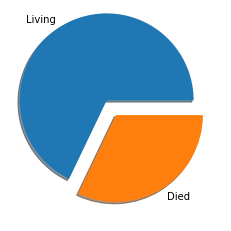

In [7]:
# No need to replace null value

# Explore data
live_len = len(data["DEATH_EVENT"][data.DEATH_EVENT == 0])
death_len = len(data["DEATH_EVENT"][data.DEATH_EVENT == 1])

arr = np.array([live_len, death_len])
labels = ['Living', 'Died']

plt.pie(arr, labels=labels, explode=[0.2,0.0], shadow=True)
plt.show()

C:\Users\Tho Le\AppData\Local\Temp\ipykernel_25016\1143476676.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data["age"])


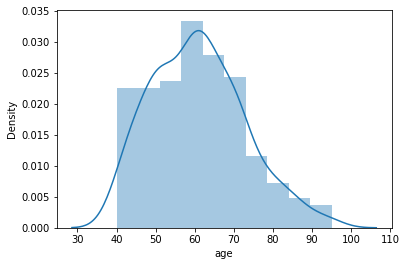

In [8]:
sns.distplot(data["age"])
plt.show()

<Axes: >

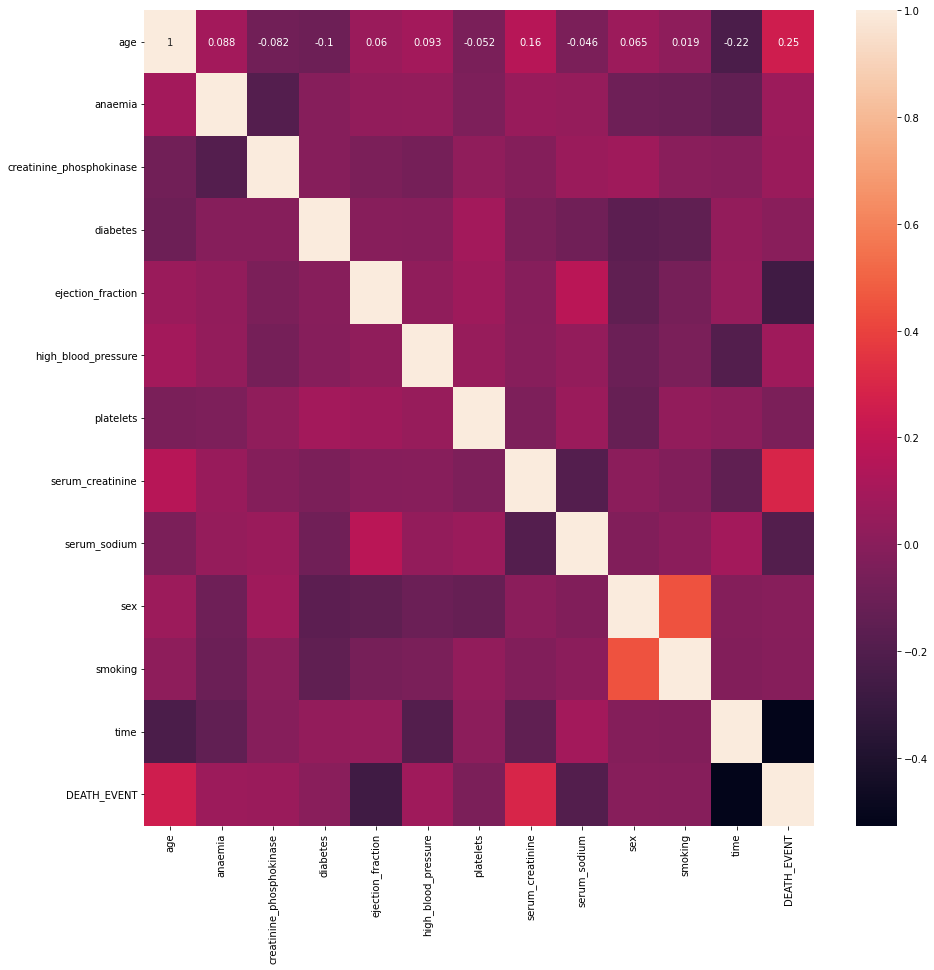

In [10]:
# Check correlation of our variables
corr = data.corr()
plt.subplots(figsize=(15,15))
sns.heatmap(corr, annot=True)

In [11]:
from sklearn.model_selection import train_test_split

X = data.drop("DEATH_EVENT", axis=1)
y = data["DEATH_EVENT"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [13]:
def add_interactions(X):
    features = X.columns
    m = len(features)
    X_int = X.copy(deep=True)

    for i in range(m):
        fi_name = features[i]
        fi_data = X[fi_name]
        for j in range(i+1, m):
            fj_name = features[j]
            fj_data = X[fj_name]
            fij_name = fi_name + "_x_" + fj_name
            X_int[fij_name] = fi_data * fj_data
    return X_int

X_train_mod = add_interactions(X_train)
X_test_mod = add_interactions(X_test)

In [14]:
X_train_mod

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,...,serum_creatinine_x_serum_sodium,serum_creatinine_x_sex,serum_creatinine_x_smoking,serum_creatinine_x_time,serum_sodium_x_sex,serum_sodium_x_smoking,serum_sodium_x_time,sex_x_smoking,sex_x_time,smoking_x_time
224,58.000,0,582,1,25,0,504000.00,1.0,138,1,...,138.0,1.0,0.0,205.0,138,0,28290,0,205,0
68,70.000,0,161,0,25,0,244000.00,1.2,142,0,...,170.4,0.0,0.0,79.2,0,0,9372,0,0,0
222,42.000,1,86,0,35,0,365000.00,1.1,139,1,...,152.9,1.1,1.1,221.1,139,139,27939,1,201,201
37,82.000,1,855,1,50,1,321000.00,1.0,145,0,...,145.0,0.0,0.0,30.0,0,0,4350,0,0,0
16,87.000,1,149,0,38,0,262000.00,0.9,140,1,...,126.0,0.9,0.0,12.6,140,0,1960,0,14,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
188,60.667,1,151,1,40,1,201000.00,1.0,136,0,...,136.0,0.0,0.0,172.0,0,0,23392,0,0,0
71,58.000,0,582,1,35,0,122000.00,0.9,139,1,...,125.1,0.9,0.9,63.9,139,139,9869,1,71,71
106,55.000,0,748,0,45,0,263000.00,1.3,137,1,...,178.1,1.3,0.0,114.4,137,0,12056,0,88,0
270,44.000,0,582,1,30,1,263358.03,1.6,130,1,...,208.0,1.6,1.6,390.4,130,130,31720,1,244,244


In [17]:
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score

def eval_model(y_test, y_pred):
    print("Accuracy: ", accuracy_score(y_test, y_pred))
    print("Precision: ", precision_score(y_test, y_pred))
    print("Recall: ", recall_score(y_test, y_pred))
    print("Confusion matrix: ", confusion_matrix(y_test, y_pred))

In [18]:
# Model
from sklearn.linear_model import LogisticRegression

lgReg = LogisticRegression(max_iter=1000)
lgReg.fit(X_train, y_train)

lgReg_pred = lgReg.predict(X_test)

eval_model(y_test, lgReg_pred)

Accuracy:  0.7888888888888889
Precision:  0.8461538461538461
Recall:  0.5945945945945946
Confusion matrix:  [[49  4]
 [15 22]]


C:\Users\Tho Le\AppData\Roaming\Python\Python310\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [19]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

lgReg_pip = make_pipeline(StandardScaler(), LogisticRegression())
lgReg_pip.fit(X_train, y_train)

lgReg_pip_pred = lgReg_pip.predict(X_test)

eval_model(y_test, lgReg_pip_pred)

Accuracy:  0.7888888888888889
Precision:  0.875
Recall:  0.5675675675675675
Confusion matrix:  [[50  3]
 [16 21]]


In [20]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV

param_grid = {'C': [0.1, 1, 10, 100, 1000],
              'gamma': [1, 0.1, 0.01, 0.001, 0.0001],
              'kernel': ['rbf']}
grid = GridSearchCV(SVC(), param_grid, refit=True, verbose=3)
grid.fit(X_train, y_train)

Fitting 5 folds for each of 25 candidates, totalling 125 fits
[CV 1/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.714 total time=   0.0s
[CV 2/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.714 total time=   0.0s
[CV 3/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.714 total time=   0.0s
[CV 4/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.714 total time=   0.0s
[CV 5/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.732 total time=   0.0s
[CV 1/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.714 total time=   0.0s
[CV 2/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.714 total time=   0.0s
[CV 3/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.714 total time=   0.0s
[CV 4/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.714 total time=   0.0s
[CV 5/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.732 total time=   0.0s
[CV 1/5] END .....C=0.1, gamma=0.01, kernel=rbf;, score=0.714 total time=   0.0s
[CV 2/5] END .....C=0.1, gamma=0.01, kernel=rbf

GridSearchCV(estimator=SVC(),
             param_grid={'C': [0.1, 1, 10, 100, 1000],
                         'gamma': [1, 0.1, 0.01, 0.001, 0.0001],
                         'kernel': ['rbf']},
             verbose=3)

In [21]:
grid_pred = lgReg_pip.predict(X_test)

eval_model(y_test, grid_pred)

Accuracy:  0.7888888888888889
Precision:  0.875
Recall:  0.5675675675675675
Confusion matrix:  [[50  3]
 [16 21]]


In [22]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import RandomizedSearchCV

def randomized_search(params, runs=20, clf=DecisionTreeClassifier(random_state=42)):
    rand_clf = RandomizedSearchCV(clf, params, n_iter=runs, cv=5, n_jobs=-1, random_state=42)
    rand_clf.fit(X_train, y_train)
    best_model = rand_clf.best_estimator_
    best_score = rand_clf.best_score_

    return best_model

randomized_search(params = {
                        'criterion': ['entropy', 'gini'],
                        'splitter': ['random', 'best'],
                        'min_weight_fraction_leaf': [0.0, 0.0025, 0.005, 0.0075, 0.01],
                        'min_samples_split': [2, 3, 4, 5, 6, 8, 10],
                        'min_samples_leaf': [1, 0.01, 0.02, 0.03, 0.04],
                        'min_impurity_decrease': [0.0, 0.0005, 0.005, 0.05, 0.10, 0.15, 0.2],
                        'max_leaf_nodes': [10, 15, 20, 25, 30, 35, 40, 45, 50, None],
                        'max_features': ['auto', 0.95, 0.90, 0.85, 0.80, 0.75, 0.70],
                        'max_depth': [None, 2, 4, 6, 8]
                    })

C:\Users\Tho Le\AppData\Roaming\Python\Python310\site-packages\sklearn\model_selection\_validation.py:528: FitFailedWarning: 
5 fits failed out of a total of 100.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
2 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\Tho Le\AppData\Roaming\Python\Python310\site-packages\sklearn\model_selection\_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "C:\Users\Tho Le\AppData\Roaming\Python\Python310\site-packages\sklearn\base.py", line 1382, in wrapper
    estimator._validate_params()
  File "C:\Users\Tho Le\AppData\Roaming\Python\Python310\site-packages\sklearn\base.py", line 436, in _validate_params
    vali

DecisionTreeClassifier(criterion='entropy', max_depth=2, max_features=0.8,
                       max_leaf_nodes=25, min_impurity_decrease=0.05,
                       min_samples_leaf=0.03, min_samples_split=8,
                       min_weight_fraction_leaf=0.0075, random_state=42)

In [23]:
ds_clf = DecisionTreeClassifier(max_depth=4, max_features=0.8,
                       max_leaf_nodes=25, min_impurity_decrease=0.05,
                       min_samples_leaf=0.03, min_samples_split=8,
                       min_weight_fraction_leaf=0.005, random_state=42,
                       splitter='random')
ds_clf.fit(X_train, y_train)
ds_clf_pred = ds_clf.predict(X_test)
eval_model(y_test, ds_clf_pred)

Accuracy:  0.7333333333333333
Precision:  0.8421052631578947
Recall:  0.43243243243243246
Confusion matrix:  [[50  3]
 [21 16]]
